IMPORT DEPENDENCIES

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split 
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

1.DATA COLLECTION

In [53]:
df=pd.read_csv(r"C:\Users\Jasin\Downloads\student_depression_dataset.csv")
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1


In [55]:
df.shape

(27901, 18)

2.EXPLORATORY DATA ANALYSIS(EDA)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [59]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


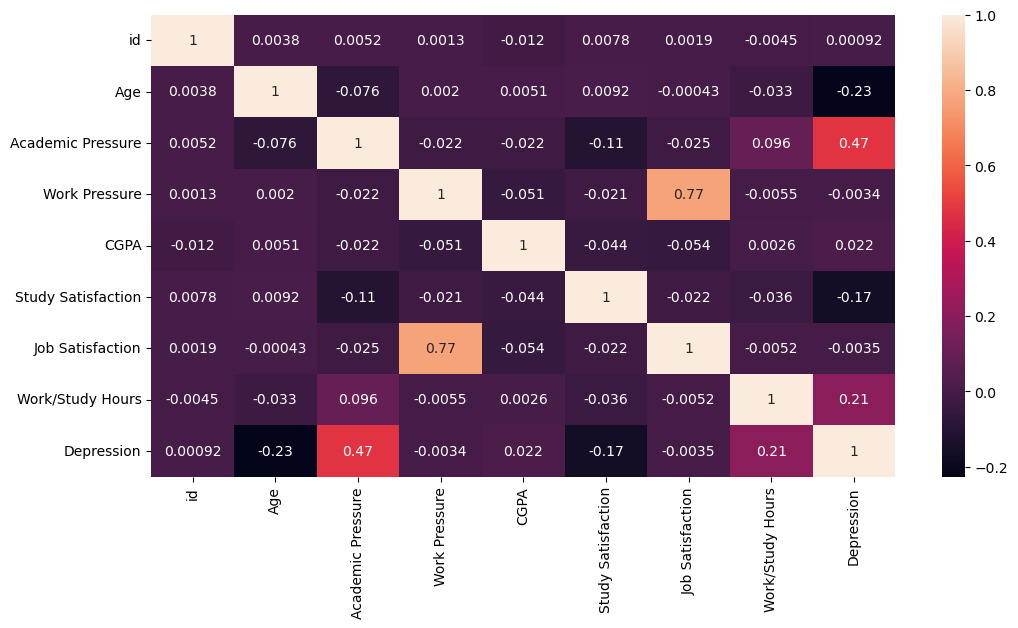

In [61]:
#To detect multicollinearity and relationships with depression
plt.figure(figsize=(12, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True)
plt.savefig('myplot_heat.png')

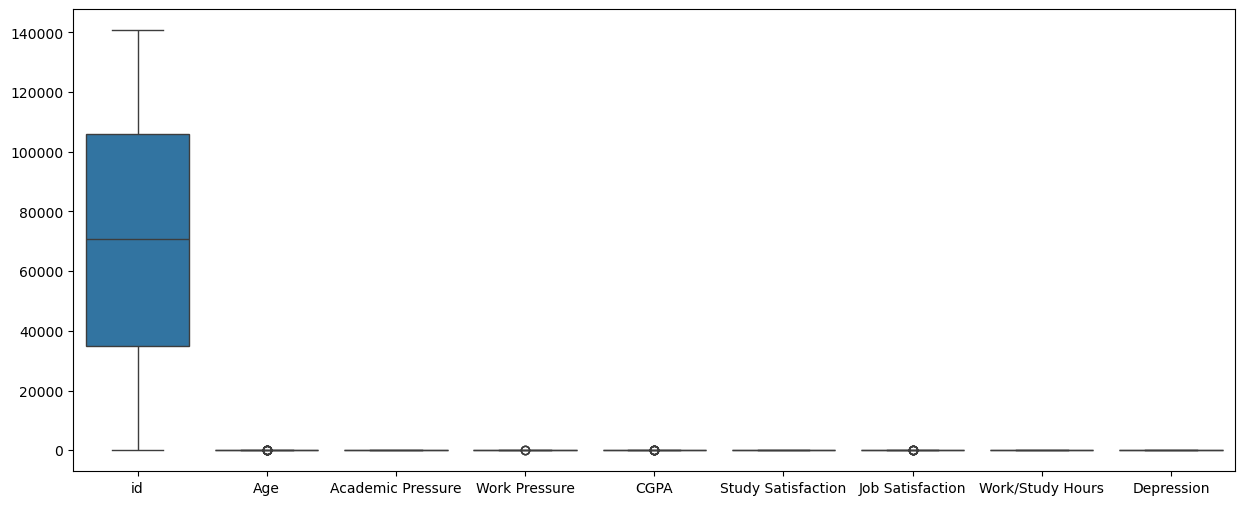

In [63]:
#to detect outliers 
plt.figure(figsize=(15, 6))
sns.boxplot(df)

plt.savefig('myplot_box.png')

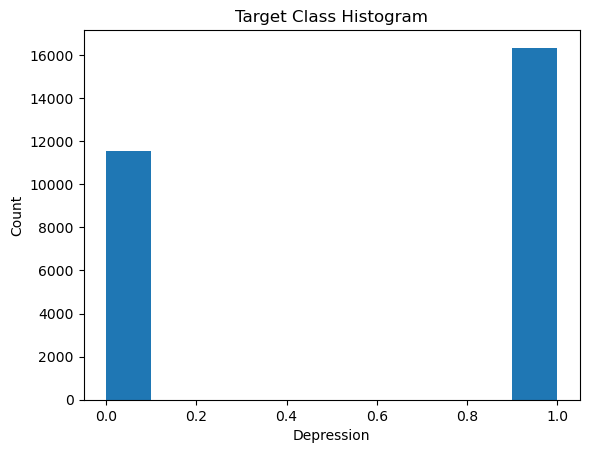

In [65]:
#To check class imbalance
plt.hist(df['Depression'])
plt.title("Target Class Histogram")
plt.xlabel("Depression")
plt.ylabel("Count")
plt.savefig('histogram.png')
plt.show()

3.DATA PREPROCESSING

In [67]:
#missing values
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [69]:
#Dropping column which is not useful for modeling
df.drop(['id'],axis=1,inplace=True)

In [71]:
# Outlier Handling
# Select only numeric columns for IQR computation
num_df = df.select_dtypes(include='number')

# Calculate Q1,Q2,Q3, and IQR
q1 = num_df.quantile(0.25)
q2 = num_df.quantile(0.50)
q3 = num_df.quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

df = df[~((num_df < lower_limit) | (num_df > upper_limit)).any(axis=1)]

In [73]:
# Encoding each categorical data
l1 = LabelEncoder()
l2 = LabelEncoder()
l3 = LabelEncoder()
l4 = LabelEncoder()
l5 = LabelEncoder()
l6 = LabelEncoder()
l7 = LabelEncoder()
l8 = LabelEncoder()
l9 = LabelEncoder()

df['Gender'] = l1.fit_transform(df['Gender'])
df['City'] = l2.fit_transform(df['City'])
df['Profession'] = l3.fit_transform(df['Profession'])
df['Sleep Duration'] = l4.fit_transform(df['Sleep Duration'])
df['Dietary Habits'] = l5.fit_transform(df['Dietary Habits'])
df['Degree'] = l6.fit_transform(df['Degree'])
df['Have you ever had suicidal thoughts ?'] = l7.fit_transform(df['Have you ever had suicidal thoughts ?'])
df['Financial Stress'] = l8.fit_transform(df['Financial Stress'])
df['Family History of Mental Illness'] = l9.fit_transform(df['Family History of Mental Illness'])

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27878 entries, 0 to 27900
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27878 non-null  int32  
 1   Age                                    27878 non-null  float64
 2   City                                   27878 non-null  int32  
 3   Profession                             27878 non-null  int32  
 4   Academic Pressure                      27878 non-null  float64
 5   Work Pressure                          27878 non-null  float64
 6   CGPA                                   27878 non-null  float64
 7   Study Satisfaction                     27878 non-null  float64
 8   Job Satisfaction                       27878 non-null  float64
 9   Sleep Duration                         27878 non-null  int32  
 10  Dietary Habits                         27878 non-null  int32  
 11  Degree 

In [77]:
#Split to Train/Test sets
x=df.drop('Depression',axis=1)
y=df['Depression']

In [79]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [81]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [83]:
y_train.value_counts()

Depression
1    13069
0     9233
Name: count, dtype: int64

In [85]:
smote = SMOTE()
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [87]:
y_train_smote.value_counts()

Depression
1    13069
0    13069
Name: count, dtype: int64

4.MODEL TRAINING AND EVALUATION

In [89]:
# Logistic Regression
model_l = LogisticRegression()
para_l = {'C': [1, 10], 'solver': ['liblinear', 'lbfgs'], 'max_iter': [100, 200]}

gscv_l = GridSearchCV(model_l, para_l, cv=5, return_train_score=True)
gscv_l.fit(x_train_smote, y_train_smote)

# Prediction
l_pred = gscv_l.predict(x_test)

# Evaluating the prediction
print("Accuracy:", accuracy_score(y_test, l_pred))
print("Precision:", precision_score(y_test, l_pred))
print("Recall:", recall_score(y_test, l_pred))
print("F1 Score:", f1_score(y_test, l_pred))
print("Best Parameters:", gscv_l.best_params_)
print("\nClassification Report:\n", classification_report(y_test, l_pred))

Accuracy: 0.8457675753228121
Precision: 0.8738317757009346
Recall: 0.8604294478527608
F1 Score: 0.8670788253477589
Best Parameters: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82      2316
           1       0.87      0.86      0.87      3260

    accuracy                           0.85      5576
   macro avg       0.84      0.84      0.84      5576
weighted avg       0.85      0.85      0.85      5576



In [43]:
# DecisionTreeClassifier
model_dt = DecisionTreeClassifier()
para_dt = {'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 10]}

gscv_dt = GridSearchCV(model_dt, para_dt, cv=5, return_train_score=True)
gscv_dt.fit(x_train_smote, y_train_smote)

# Prediction
dt_pred = gscv_dt.predict(x_test)

# Evaluating the prediction
print("Decision Tree\nAccuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))
print("Best Parameters:", gscv_dt.best_params_)
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Decision Tree
Accuracy: 0.8210186513629842
Precision: 0.8366071428571429
Recall: 0.8622699386503068
F1 Score: 0.8492447129909365
Best Parameters: {'criterion': 'gini', 'max_depth': 10}

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78      2316
           1       0.84      0.86      0.85      3260

    accuracy                           0.82      5576
   macro avg       0.82      0.81      0.81      5576
weighted avg       0.82      0.82      0.82      5576



In [45]:
# RandomForestClassifier
model_rf = RandomForestClassifier()
para_rf = {'n_estimators': [10, 50, 100], 'max_depth': [3, 5, 10, None]}

gscv_rf = GridSearchCV(model_rf, para_rf, cv=5, return_train_score=True)
gscv_rf.fit(x_train_smote, y_train_smote)

# Prediction
rf_pred = gscv_rf.predict(x_test)

# Evaluating the prediction
print("Random Forest\nAccuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("Best Parameters:", gscv_rf.best_params_)
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.8403873744619799
Precision: 0.8547904191616766
Recall: 0.8757668711656442
F1 Score: 0.8651515151515151
Best Parameters: {'max_depth': None, 'n_estimators': 100}

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80      2316
           1       0.85      0.88      0.87      3260

    accuracy                           0.84      5576
   macro avg       0.84      0.83      0.83      5576
weighted avg       0.84      0.84      0.84      5576



In [95]:
# SVC
model_svc = SVC()
para_svc = {'C': [1, 10], 'kernel': ['linear', 'rbf']}
gscv_svc = GridSearchCV(model_svc, para_svc, cv=5, return_train_score=True)
gscv_svc.fit(x_train_smote, y_train_smote)

# Prediction
svc_pred = gscv_svc.predict(x_test)

# Evaluating the prediction
print("SVC\nAccuracy:", accuracy_score(y_test, svc_pred))
print("Precision:", precision_score(y_test, svc_pred))
print("Recall:", recall_score(y_test, svc_pred))
print("F1 Score:", f1_score(y_test, svc_pred))
print("Best Parameters:", gscv_svc.best_params_)
print("\nClassification Report:\n", classification_report(y_test, svc_pred))

SVC
Accuracy: 0.8342898134863702
Precision: 0.8569682151589242
Recall: 0.8601226993865031
F1 Score: 0.8585425597060624
Best Parameters: {'C': 10, 'kernel': 'rbf'}

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80      2316
           1       0.86      0.86      0.86      3260

    accuracy                           0.83      5576
   macro avg       0.83      0.83      0.83      5576
weighted avg       0.83      0.83      0.83      5576



In [47]:
# KNeighborsClassifier
model_knn = KNeighborsClassifier()
para_knn={'n_neighbors':[3,5],'weights': ['uniform', 'distance']}
gscv_knn = GridSearchCV(model_knn, para_knn, cv=5, return_train_score=True)
gscv_knn.fit(x_train_smote, y_train_smote)

# Prediction
knn_pred = gscv_knn.predict(x_test)

# Evaluating the prediction
print("KNN\nAccuracy:", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall:", recall_score(y_test, knn_pred))
print("F1 Score:", f1_score(y_test, knn_pred))
print("Best Parameters:", gscv_knn.best_params_)
print("\nClassification Report:\n", classification_report(y_test, knn_pred))

KNN
Accuracy: 0.8115136298421808
Precision: 0.8437597261126673
Recall: 0.8315950920245399
F1 Score: 0.8376332457902055
Best Parameters: {'n_neighbors': 5, 'weights': 'distance'}

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.78      0.78      2316
           1       0.84      0.83      0.84      3260

    accuracy                           0.81      5576
   macro avg       0.81      0.81      0.81      5576
weighted avg       0.81      0.81      0.81      5576



In [91]:
# XGBoost
model_xgb = XGBClassifier()
para_xgb = {'n_estimators': [50, 100, 150], 'max_depth': [3, 5, 7]}
gscv_xgb = GridSearchCV(model_xgb, para_xgb, cv=5, return_train_score=True)
gscv_xgb.fit(x_train_smote, y_train_smote)

# Prediction
xgb_pred = gscv_xgb.predict(x_test)

# Evaluating the prediction
print("XGBoost\nAccuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("Best Parameters:", gscv_xgb.best_params_)
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))

XGBoost
Accuracy: 0.8472022955523673
Precision: 0.8581201665675193
Recall: 0.8849693251533742
F1 Score: 0.8713379643612201
Best Parameters: {'max_depth': 3, 'n_estimators': 150}

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2316
           1       0.86      0.88      0.87      3260

    accuracy                           0.85      5576
   macro avg       0.84      0.84      0.84      5576
weighted avg       0.85      0.85      0.85      5576



In [99]:
# Naivebayes
model_nb = GaussianNB()
param_nb = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}  
gscv_nb = GridSearchCV(model_nb, param_nb, cv=5, return_train_score=True)
gscv_nb.fit(x_train_smote, y_train_smote)

# Prediction
nb_pred = gscv_nb.predict(x_test)

# Evaluating the prediction
print("Naive Bayes\nAccuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall:", recall_score(y_test, nb_pred))
print("F1 Score:", f1_score(y_test, nb_pred))
print("Best Parameters:", gscv_nb.best_params_)
print("\nClassification Report:\n", classification_report(y_test, nb_pred))

Naive Bayes
Accuracy: 0.5798063127690101
Precision: 0.9781021897810219
Recall: 0.28773006134969326
F1 Score: 0.44465513154776015
Best Parameters: {'var_smoothing': 1e-09}

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.99      0.66      2316
           1       0.98      0.29      0.44      3260

    accuracy                           0.58      5576
   macro avg       0.74      0.64      0.55      5576
weighted avg       0.78      0.58      0.53      5576



In [45]:
# Save model
pickle.dump(gscv_xgb, open('gscv_xgb.pkl', 'wb'))

# Save each LabelEncoder separately
pickle.dump(l1, open('l1.pkl', 'wb'))
pickle.dump(l2, open('l2.pkl', 'wb'))
pickle.dump(l3, open('l3.pkl', 'wb'))
pickle.dump(l4, open('l4.pkl', 'wb'))
pickle.dump(l5, open('l5.pkl', 'wb'))
pickle.dump(l6, open('l6.pkl', 'wb'))
pickle.dump(l7, open('l7.pkl', 'wb'))
pickle.dump(l8, open('l8.pkl', 'wb'))
pickle.dump(l9, open('l9.pkl', 'wb'))

# Save the StandardScaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [47]:
# Load trained model
model = pickle.load(open('gscv_xgb.pkl', 'rb'))

# Load LabelEncoders
l1 = pickle.load(open('l1.pkl', 'rb'))
l2 = pickle.load(open('l2.pkl', 'rb'))
l3 = pickle.load(open('l3.pkl', 'rb'))
l4 = pickle.load(open('l4.pkl', 'rb'))
l5 = pickle.load(open('l5.pkl', 'rb'))
l6 = pickle.load(open('l6.pkl', 'rb'))
l7 = pickle.load(open('l7.pkl', 'rb'))
l8 = pickle.load(open('l8.pkl', 'rb'))
l9 = pickle.load(open('l9.pkl', 'rb'))

# Load StandardScaler
scaler = pickle.load(open('scaler.pkl', 'rb'))